In [2]:
from typing import TypedDict, Dict, List
from langgraph.graph import StateGraph , START , END
from IPython.display import display ,Image
import random

In [3]:
class AgentState(TypedDict):
    player_name:str
    target_number:int
    guesses:List[int]
    attempts:int
    hint:str
    lower_bound:int
    upper_bound:int

In [4]:
def setup(state:AgentState)->AgentState:
    state["player_name"] = f"Welcome, {state['player_name']}!"
    state["target_number"] = random.randint(1, 20)
    state["guesses"] = []
    state["attempts"] = 0
    state["hint"] = "Game started! Try to guess the number."
    state["lower_bound"] = 1 
    state["upper_bound"] = 20 
    print(f"{state['player_name']} The game has begun. I'm thinking of a number between 1 and 20.")
    return state

In [5]:

def guess_node(state:AgentState)->AgentState:
    possible_guess = [
        i 
        for i in range (
            state['lower_bound'],
            state['upper_bound']+1)
            if i not in state['guesses'] 
    ]

    if possible_guess:
        present_guess = random.choice(possible_guess)
    else:
        present_guess = random.randint(state['lower_bound'],state['upper_bound'])


    state['attempts'] += 1
    state['guesses'].append(present_guess)
    print(f"Attempt: {state['attempts']} ,Guess : {state['guesses']}")
    return state

In [6]:
def hint_node(state: AgentState) -> AgentState:
    """Here we provide a hint based on the last guess and update the bounds"""
    latest_guess = state["guesses"][-1]
    target = state["target_number"]
    
    if latest_guess < target:
        state["hint"] = f"The number {latest_guess} is too low. Try higher!"
        
        state["lower_bound"] = max(state["lower_bound"], latest_guess + 1)
        print(f"Hint: {state['hint']}")
        
    elif latest_guess > target:
        state["hint"] = f"The number {latest_guess} is too high. Try lower!"
      
        state["upper_bound"] = min(state["upper_bound"], latest_guess - 1)
        print(f"Hint: {state['hint']}")
    else:
        state["hint"] = f"Correct! You found the number {target} in {state['attempts']} attempts."
        print(f"Success! {state['hint']}")
    
    return state

In [7]:
def should_I_continue(state:AgentState)->str:
    latest_guess = state['guesses'][-1]
    if state['attempts'] >=7:
        print(f"Game OVER !!, Maximum attempts REACHED !!, the Number was {state['target_number']}")
        return "end"
    elif latest_guess == state['target_number']:
        print(f"You Won , Number Found")
        return "end"
    else :
        print(f"{state['attempts']}/7 attempts are used")
        return 'continue'

In [8]:
tess = AgentState(player_name="Ikrama")
A1=setup(tess)
G1= guess_node(A1)
H1=hint_node(G1)

    

Welcome, Ikrama! The game has begun. I'm thinking of a number between 1 and 20.
Attempt: 1 ,Guess : [9]
Hint: The number 9 is too high. Try lower!


In [9]:
graph = StateGraph(AgentState)
graph.add_node("setup",setup)
graph.add_node("guess",guess_node)
graph.add_node("hint",hint_node)

graph.add_edge("setup","guess") 
graph.add_edge("guess","hint")

graph.add_conditional_edges(
    "hint",
    should_I_continue,
    {"continue":"guess",
     "end": END}
)

graph.set_entry_point("setup")
app = graph.compile()

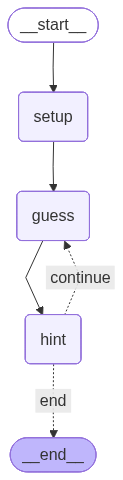

In [10]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
t1 = AgentState(player_name="Ikrama",  guesses=[], attempts=0, hint="", lower_bound=0, upper_bound=20)
result = app.invoke({"player_name":"ikraama","lower_bound":0,"upper_bound":20})

Welcome, ikraama! The game has begun. I'm thinking of a number between 1 and 20.
Attempt: 1 ,Guess : [7]
Hint: The number 7 is too high. Try lower!
1/7 attempts are used
Attempt: 2 ,Guess : [7, 4]
Hint: The number 4 is too low. Try higher!
2/7 attempts are used
Attempt: 3 ,Guess : [7, 4, 6]
Hint: The number 6 is too high. Try lower!
3/7 attempts are used
Attempt: 4 ,Guess : [7, 4, 6, 5]
Success! Correct! You found the number 5 in 4 attempts.
You Won , Number Found


In [ ]:
g1=guess_node(t1)
h=hint_node(g1)
h

Attempt: 3 ,Guess : [15, 7, 17]


KeyError: 'target_number'

In [ ]:
# def my_Loop(state:AgentState)->AgentState:
#     while state['hint']!= "Guess is correct !!" :
#         hint_node(state)

# my_Loop(g1)